# B_S3.6 - Metric Equitability and K-Progression Analysis

Goal: evaluate whether metrics are **equitable** — do they give comparable scores across different relationship types at the same signal strength?

Inspired by Reshef et al. (2011), this notebook plots metric Z-scores and detection rates against SNR for each relationship family. An equitable metric produces similar scores for relationships of similar noise level, regardless of the functional form.

Additionally, this notebook compares **single vs multi-metric** detection rates by relationship type, showing why `dcor` alone outperforms larger metric combinations under the max-Z framework.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ROOT = Path.cwd()
if not (ROOT / 'output' / 'S3' / 'permutation_all.parquet').exists() and (ROOT / 'B' / 'output' / 'S3' / 'permutation_all.parquet').exists():
    ROOT = ROOT / 'B'

S1_DIR = ROOT / 'output' / 'S1'
S3_DIR = ROOT / 'output' / 'S3'
OUT_DIR = ROOT / 'output' / 'S3.6'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260623
ALPHA = 0.05
TRAIN_FRACTION = 0.5
EXCLUDE_BANDWIDTH = True
MERGE_DCOR_DCOV = True

print(f'ROOT = {ROOT}')

ROOT = /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/B


## 1. Load Data and Recreate S3.4 Split

Same MINE-covered subset and stratified train/validation split as S3.4 and S3.5.

In [2]:
df = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'family_name', 'snr', 'spread_pattern', 'x_distribution']
for col in meta_cols:
    if col not in cases_main.columns:
        cases_main[col] = np.nan
    if col not in cases_null.columns:
        cases_null[col] = np.nan

cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

is_null = df['family_id'] == 'Null'
is_const = df['spread_pattern'] == 'constant'
df['category'] = 'mean+variance'
df.loc[is_null & is_const, 'category'] = 'true_null'
df.loc[~is_null & is_const, 'category'] = 'mean_only'
df.loc[is_null & ~is_const, 'category'] = 'variance_only'

mine_z = [c for c in Z_COLS if c in ('z_mic', 'z_mas', 'z_mev', 'z_mcn')]
df = df[df[mine_z].notna().all(axis=1)].reset_index(drop=True)
print(f'MINE-covered cases: {len(df):,}')

rng = np.random.default_rng(RANDOM_SEED)
df['split'] = 'validation'
for _, idx in df.groupby(['category', 'x_distribution'], dropna=False).groups.items():
    idx = np.array(list(idx)).copy()
    rng.shuffle(idx)
    n_train = int(round(len(idx) * TRAIN_FRACTION))
    if len(idx) > 1:
        n_train = min(max(n_train, 1), len(idx) - 1)
    df.loc[idx[:n_train], 'split'] = 'train'

train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
print(f'Train: {len(train):,}; Validation: {len(validation):,}')
print(df['category'].value_counts().to_string())

MINE-covered cases: 9,008
Train: 4,508; Validation: 4,500
category
true_null        4032
variance_only    2976
mean+variance    1018
mean_only         982


## 2. Metric Setup

In [3]:
def metric_display(col):
    name = col.replace('z_', '')
    return {'abs_pearson_r': '|Pearson|', 'abs_spearman_rho': '|Spearman|',
            'abs_covariance': '|Covariance|', 'mic_minus_r2': 'MIC\u2212r\u00b2'}.get(name, name)

METRIC_DISPLAY = {c: metric_display(c) for c in Z_COLS}

METRIC_GROUPS = {}
for c in Z_COLS:
    name = c.replace('z_', '')
    if name in ('pearson', 'spearman', 'abs_pearson_r', 'abs_spearman_rho', 'abs_covariance'):
        METRIC_GROUPS[c] = 'correlation'
    elif 'dcor' in name or 'dcov' in name:
        METRIC_GROUPS[c] = 'distance'
    elif 'ep_' in name or 'pf_' in name or 'seg_' in name:
        METRIC_GROUPS[c] = 'slope'
    elif 'bin_' in name or name == 'eta2':
        METRIC_GROUPS[c] = 'bin'
    elif 'dist_' in name:
        METRIC_GROUPS[c] = 'distribution'
    elif name in ('mic', 'mas', 'mev', 'mcn', 'mic_minus_r2'):
        METRIC_GROUPS[c] = 'mine'
    elif name == 'lowess_r2':
        METRIC_GROUPS[c] = 'nonlinear'
    else:
        METRIC_GROUPS[c] = 'other'

train_null = train[train['category'] == 'true_null']
calib_rows = []
for zc in Z_COLS:
    z_null = train_null[zc].dropna()
    pc = zc.replace('z_', 'p_')
    p_null = train_null[pc].dropna() if pc in train_null.columns else pd.Series(dtype=float)
    emp_fpr = float((p_null <= ALPHA).mean()) if len(p_null) else np.nan
    calib_rows.append({
        'metric': zc, 'mean_null': float(z_null.mean()) if len(z_null) else np.nan,
        'std_null': float(z_null.std()) if len(z_null) > 1 else np.nan, 'emp_fpr': emp_fpr,
    })
calib = pd.DataFrame(calib_rows)
calib['flagged'] = (calib['mean_null'].abs() > 1.0) | (calib['std_null'] < 0.3) | (calib['std_null'] > 3.0) | (calib['emp_fpr'] > 0.15)

SAFE_METRICS = calib.loc[~calib['flagged'], 'metric'].tolist()
if EXCLUDE_BANDWIDTH:
    SAFE_METRICS = [m for m in SAFE_METRICS if '_bw_' not in m]
if MERGE_DCOR_DCOV and 'z_dcov' in SAFE_METRICS and 'z_dcor' in SAFE_METRICS:
    SAFE_METRICS = [m for m in SAFE_METRICS if m != 'z_dcov']

print(f'Safe metrics: {len(SAFE_METRICS)}')

Safe metrics: 35


## 3. Z-score Equitability: Mean Z-score vs SNR by Relationship Family

An equitable metric produces similar Z-scores for different relationship types at the same SNR level. All families appear as overlapping lines when the metric is equitable; they fan out when the metric favours specific relationship shapes.

Only mean-containing cases (mean_only + mean+variance) are shown because they have finite SNR values.

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_93978/3969383789.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fam = plt.cm.get_cmap('tab20', max(len(families), 2))


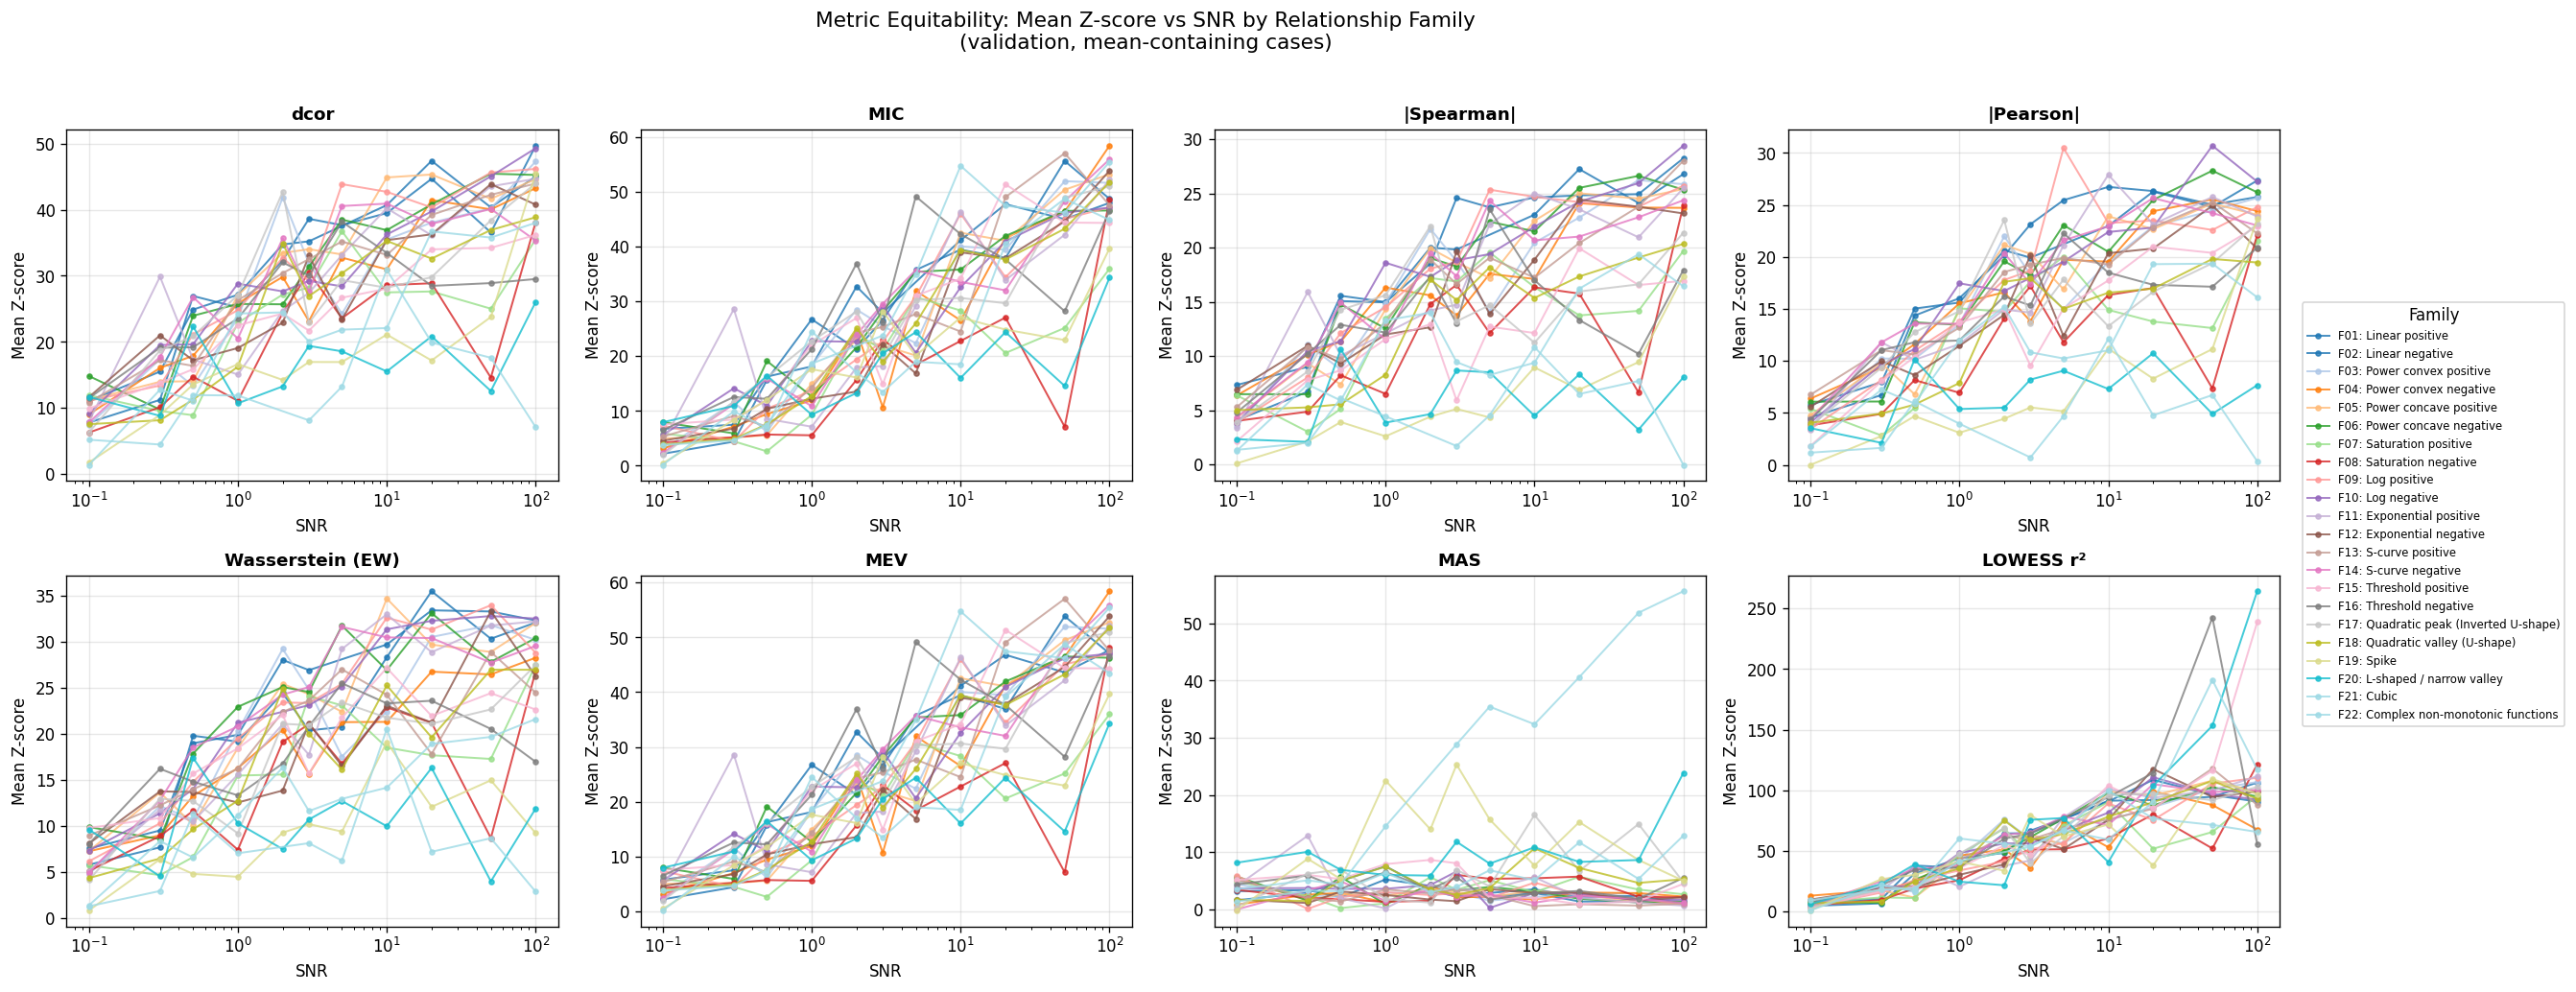

Families: 22, SNR levels: [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
Mean-signal validation cases: 921


In [4]:
EQUITABILITY_METRICS = [
    ('z_dcor', 'dcor'),
    ('z_mic', 'MIC'),
    ('z_abs_spearman_rho', '|Spearman|'),
    ('z_abs_pearson_r', '|Pearson|'),
    ('z_ew_dist_wass', 'Wasserstein (EW)'),
    ('z_mev', 'MEV'),
    ('z_mas', 'MAS'),
    ('z_lowess_r2', 'LOWESS r\u00b2'),
]
EQUITABILITY_METRICS = [(z, d) for z, d in EQUITABILITY_METRICS if z in SAFE_METRICS]

mean_signal = validation[
    validation['category'].isin(['mean_only', 'mean+variance']) &
    validation['snr'].notna() & np.isfinite(validation['snr'])
].copy()

if 'family_name' in mean_signal.columns and mean_signal['family_name'].notna().any():
    mean_signal['family_label'] = mean_signal['family_id'].astype(str) + ': ' + mean_signal['family_name'].astype(str)
else:
    mean_signal['family_label'] = mean_signal['family_id'].astype(str)

families = sorted(mean_signal['family_label'].unique())
snr_levels = sorted(mean_signal['snr'].unique())

cmap_fam = plt.cm.get_cmap('tab20', max(len(families), 2))
family_colors = {f: cmap_fam(i) for i, f in enumerate(families)}

n_metrics = len(EQUITABILITY_METRICS)
n_cols = 4
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.2 * n_rows))
axes_flat = np.array(axes).flatten()

for idx, (zcol, display_name) in enumerate(EQUITABILITY_METRICS):
    ax = axes_flat[idx]
    for family in families:
        sub = mean_signal[mean_signal['family_label'] == family]
        grouped = sub.groupby('snr')[zcol].mean()
        ax.plot(grouped.index, grouped.values, '-o', markersize=3,
                color=family_colors[family], label=family, alpha=0.8, lw=1.2)

    ax.set_xlabel('SNR')
    ax.set_ylabel('Mean Z-score')
    ax.set_title(display_name, fontsize=11, fontweight='bold')
    if len(snr_levels) > 3 and max(snr_levels) / min(snr_levels) > 5:
        ax.set_xscale('log')

for idx in range(n_metrics, len(axes_flat)):
    axes_flat[idx].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=7, title='Family')

fig.suptitle('Metric Equitability: Mean Z-score vs SNR by Relationship Family\n(validation, mean-containing cases)',
             fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig1_zscore_equitability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Families: {len(families)}, SNR levels: {snr_levels}')
print(f'Mean-signal validation cases: {len(mean_signal):,}')

## 4. Detection Rate Equitability: Detection Rate vs SNR by Relationship Family

Same layout as \u00a73, but the y-axis is detection rate (fraction of cases with Z > train-null threshold at alpha=0.05).

This is the operational version: it directly shows which families each metric can and cannot detect at each signal strength.

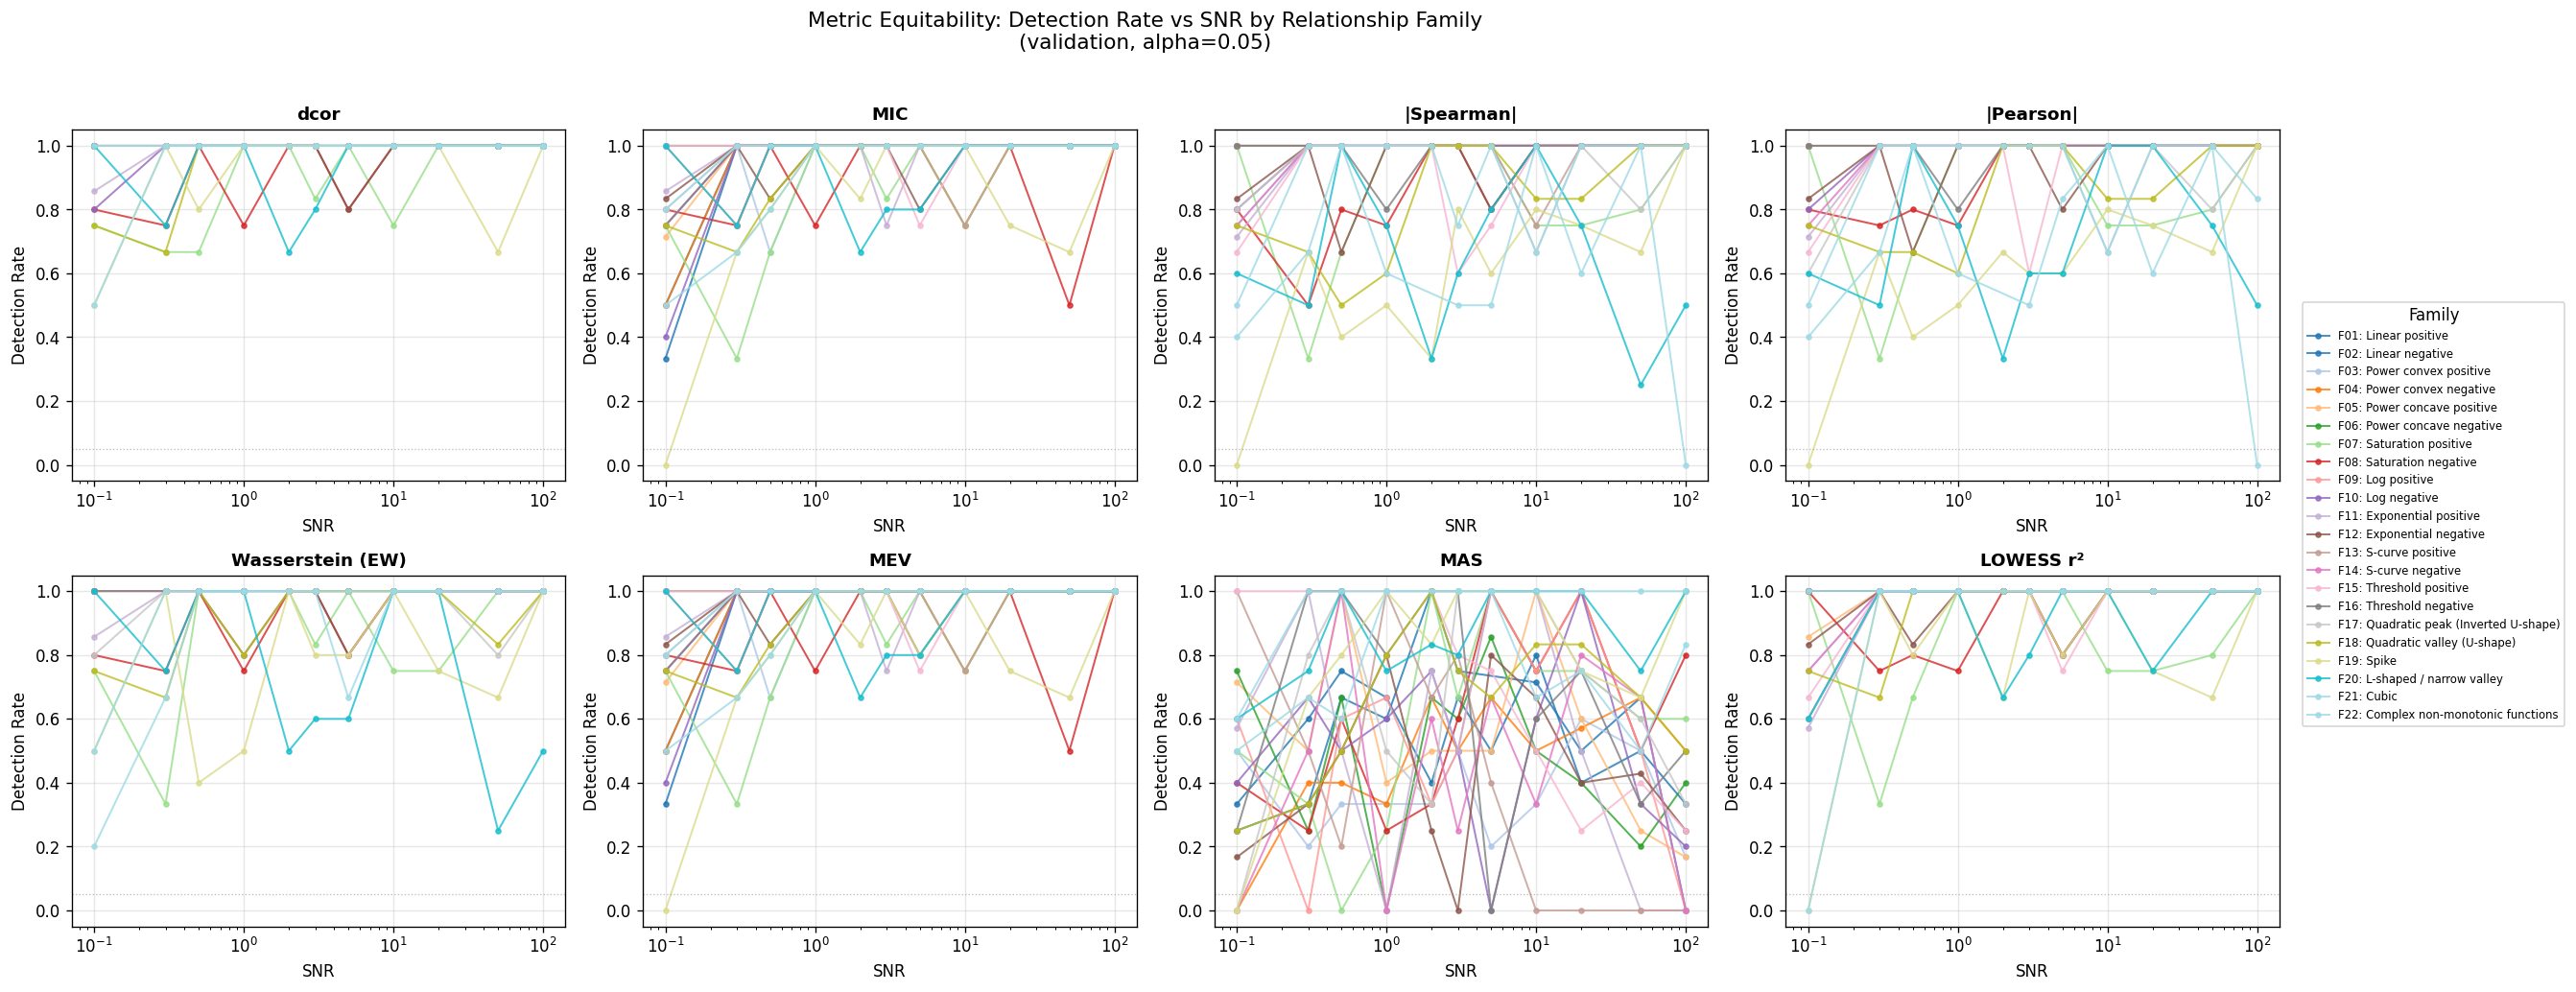

In [5]:
thresholds = {}
for zcol, _ in EQUITABILITY_METRICS:
    null_z = train[train['category'] == 'true_null'][zcol].dropna()
    thresholds[zcol] = float(np.nanpercentile(null_z, 100 * (1 - ALPHA)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.2 * n_rows))
axes_flat = np.array(axes).flatten()

for idx, (zcol, display_name) in enumerate(EQUITABILITY_METRICS):
    ax = axes_flat[idx]
    thresh = thresholds[zcol]
    for family in families:
        sub = mean_signal[mean_signal['family_label'] == family]
        rates = sub.groupby('snr')[zcol].apply(lambda x: float((x > thresh).mean()))
        ax.plot(rates.index, rates.values, '-o', markersize=3,
                color=family_colors[family], label=family, alpha=0.8, lw=1.2)

    ax.set_xlabel('SNR')
    ax.set_ylabel('Detection Rate')
    ax.set_title(display_name, fontsize=11, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(ALPHA, color='gray', ls=':', alpha=0.5, lw=0.8)
    if len(snr_levels) > 3 and max(snr_levels) / min(snr_levels) > 5:
        ax.set_xscale('log')

for idx in range(n_metrics, len(axes_flat)):
    axes_flat[idx].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=7, title='Family')

fig.suptitle('Metric Equitability: Detection Rate vs SNR by Relationship Family\n(validation, alpha=0.05)',
             fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_detection_equitability.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. K-Progression: Single vs Multi-Metric Detection by Relationship Type

Compares the best metric combos from S3.4 at k=1, k=2, k=3, and the full safe set. Each combo uses the max-Z statistic with its own train-null threshold.

This heatmap answers: does adding metrics to dcor improve detection for any specific relationship type?

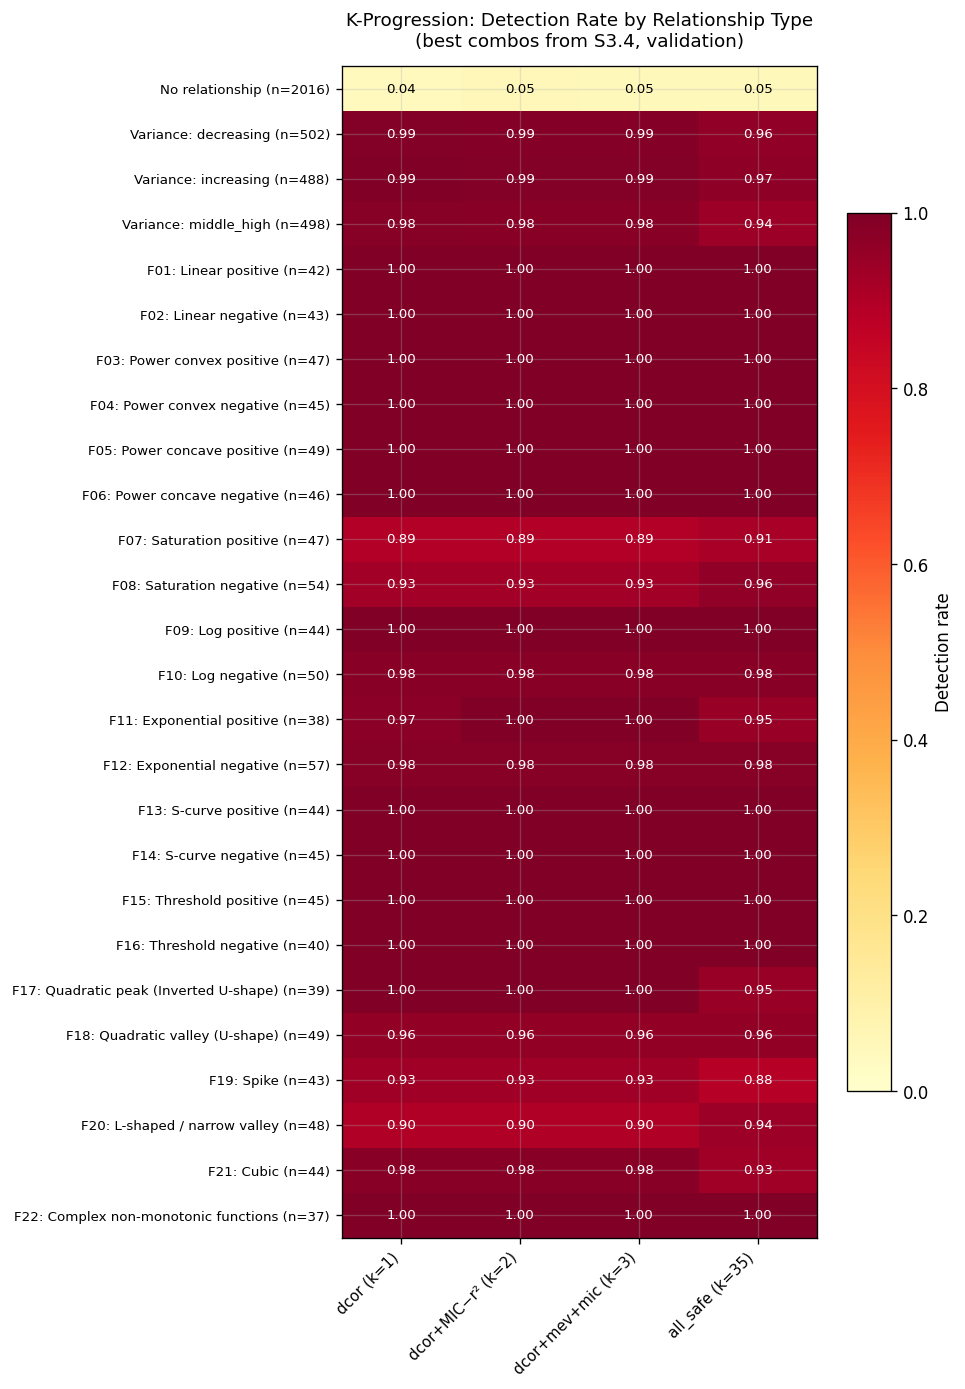

Combo thresholds (from train null):
  dcor (k=1): threshold=1.8756 (k=1)
  dcor+MIC−r² (k=2): threshold=2.0274 (k=2)
  dcor+mev+mic (k=3): threshold=2.0309 (k=3)
  all_safe (k=35): threshold=3.5363 (k=35)

Saved to /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/B/output/S3.6


In [6]:
def fit_combo_threshold(metrics, alpha=ALPHA):
    metrics = [m for m in metrics if m in Z_COLS]
    T_null = train[train['category'] == 'true_null'][metrics].max(axis=1).dropna()
    return float(np.nanpercentile(T_null, 100 * (1 - alpha)))

k_combos = {
    'dcor (k=1)': ['z_dcor'],
    'dcor+MIC\u2212r\u00b2 (k=2)': ['z_dcor', 'z_mic_minus_r2'],
    'dcor+mev+mic (k=3)': ['z_dcor', 'z_mev', 'z_mic'],
    'all_safe (k=%d)' % len(SAFE_METRICS): SAFE_METRICS,
}

def relation_label(row):
    if row['category'] == 'true_null':
        return 'No relationship'
    if row['category'] == 'variance_only':
        return f"Variance: {row['spread_pattern']}"
    fname = row.get('family_name', '')
    if pd.notna(fname) and str(fname) != 'nan':
        return f"{row['family_id']}: {fname}"
    return str(row['family_id'])

validation = validation.copy()
validation['relationship_type'] = validation.apply(relation_label, axis=1)

family_order = ['No relationship']
var_patterns = sorted(validation.loc[validation['category'] == 'variance_only', 'spread_pattern'].dropna().unique())
family_order += [f'Variance: {p}' for p in var_patterns]
fam_meta = (validation[validation['family_id'].str.startswith('F', na=False)]
            [['family_id', 'family_name']].drop_duplicates().sort_values('family_id'))
family_order += [f'{r.family_id}: {r.family_name}' if pd.notna(r.family_name) else r.family_id
                 for r in fam_meta.itertuples(index=False)]

rows = []
for combo_name, metrics in k_combos.items():
    threshold = fit_combo_threshold(metrics)
    T_val = validation[metrics].max(axis=1)
    detected = T_val > threshold
    for rt in family_order:
        mask = validation['relationship_type'] == rt
        if mask.sum() == 0:
            continue
        rows.append({'combo': combo_name, 'relationship_type': rt,
                     'detection_rate': float(detected[mask].mean()),
                     'n': int(mask.sum()), 'threshold': threshold})

k_long = pd.DataFrame(rows)
k_table = k_long.pivot(index='relationship_type', columns='combo', values='detection_rate')
k_table = k_table.reindex(index=[r for r in family_order if r in k_table.index])
k_table = k_table.reindex(columns=list(k_combos.keys()))
k_counts = k_long.drop_duplicates(subset=['relationship_type']).set_index('relationship_type')['n']

nr, nc = k_table.shape
fig_w = max(8, 0.85 * nc + 3.5)
fig_h = max(3.2, 0.38 * nr + 1.8)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
im = ax.imshow(k_table.values, cmap='YlOrRd', vmin=0.0, vmax=1.0, aspect='auto')

ax.set_xticks(np.arange(nc))
ax.set_xticklabels(k_table.columns, rotation=45, ha='right', fontsize=9)
ylabels = [f'{idx} (n={int(k_counts.loc[idx])})' if idx in k_counts.index else str(idx)
           for idx in k_table.index]
ax.set_yticks(np.arange(nr))
ax.set_yticklabels(ylabels, fontsize=8)

for i in range(nr):
    for j in range(nc):
        val = k_table.iat[i, j]
        text = '' if pd.isna(val) else f'{val:.2f}'
        color = 'white' if pd.notna(val) and val >= 0.65 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=8, color=color)

ax.set_title('K-Progression: Detection Rate by Relationship Type\n(best combos from S3.4, validation)', fontsize=11, pad=12)
cbar = fig.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label('Detection rate')
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig3_k_progression_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

print('Combo thresholds (from train null):')
for combo_name, metrics in k_combos.items():
    threshold = fit_combo_threshold(metrics)
    print(f'  {combo_name}: threshold={threshold:.4f} (k={len(metrics)})')

k_table.to_csv(OUT_DIR / 'k_progression_by_relationship_type.csv', float_format='%.6f')
print(f'\nSaved to {OUT_DIR}')

## 6. Readout

**Fig. 1 (Z-score equitability)**: An equitable metric shows overlapping family lines. Families that separate at the same SNR indicate the metric is biased toward certain relationship shapes.

**Fig. 2 (Detection rate equitability)**: The operational version. A metric that reaches 100% detection at the same SNR for all families is both equitable and powerful.

**Fig. 3 (K-progression)**: If adding metrics does not turn any cell from low to high, the multiple-comparison penalty is the only effect of increasing k \u2014 explaining why k=1 (dcor) is the optimal choice.